In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from fret import FReT_forecast, mae

# Sunspot Number Forecasting with FReT

This notebook demonstrates the application of the FReT (Forecasting using Recurrence Topology) algorithm to predicting the monthly sunspot number, a key indicator of solar activity. The dataset contains approximately 270 years of observations from the SIDC/SILSO solar observation database. We explore two approaches to cycle-based forecasting: **min-min** (predicting from minimum to minimum) and **max-max** (predicting from maximum to maximum), and evaluate the algorithm's ability to forecast future solar cycles.

## Solar Data

Data obtained from: https://www.sidc.be/SILSO/datafiles  
Monthly mean total sunspot number (1749-now): SN_m_tot_V2.0.csv  
13-month smoothed monthly total sunspot number (1749-now): SN_ms_tot_V2.0.csv

In [2]:
def read_csv_numpy(fn):
    """
    Parse SIDC/SILSO sunspot number CSV files.

    Args:
        fn: Filepath to the CSV file.

    Returns:
        Structured NumPy array with fields: datetime, datetime_float, sn.
    """

    def convert_sn(x):
        return float(x.strip())

    data = np.genfromtxt(
        fn,
        delimiter=";",
        usecols=(0, 1, 2, 3),
        names=["year", "month", "datetime_float", "sn"],
        dtype=[("year", "i4"), ("month", "i4"), ("datetime_float", "f8"), ("sn", "f8")],
        converters={3: convert_sn},
        invalid_raise=False,
    )

    dates_str = np.array(
        [f"{int(y)}-{int(m):02d}-01" for y, m in zip(data["year"], data["month"])]
    )
    dates = dates_str.astype("datetime64[D]")

    final_data = np.empty(
        len(data),
        dtype=[("datetime", "datetime64[D]"), ("datetime_float", "f8"), ("sn", "f8")],
    )

    final_data["datetime"] = dates
    final_data["datetime_float"] = data["datetime_float"]
    final_data["sn"] = data["sn"]

    return final_data

In [3]:
sn = read_csv_numpy("../data/SN_m_tot_V2.0.csv")  # Monthly mean total sunspot number
sn_smoothed = read_csv_numpy(
    "../data/SN_ms_tot_V2.0.csv"
)  # 13-month smoothed monthly total sunspot number

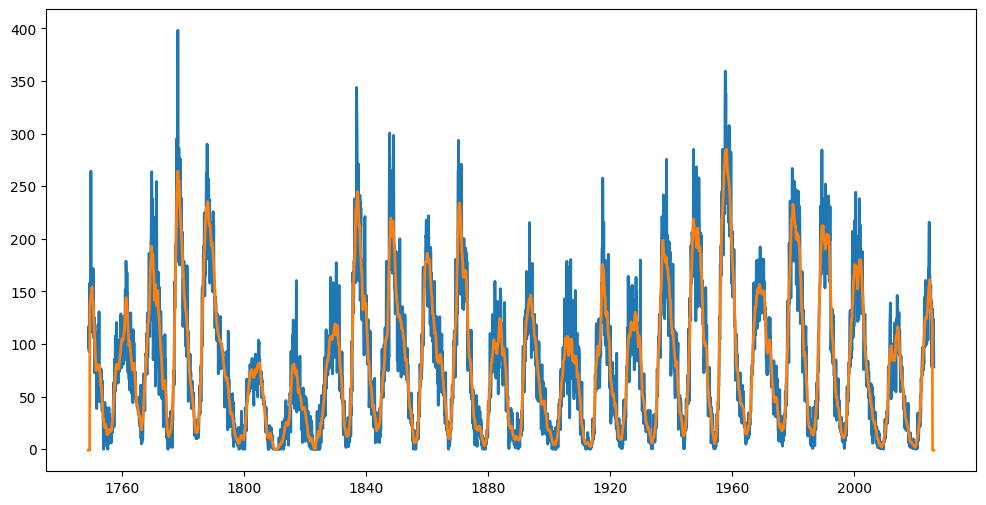

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(sn["datetime"], sn["sn"], linewidth=2)
plt.plot(sn_smoothed["datetime"], sn_smoothed["sn"], linewidth=2)

## Split by Cycles

Solar activity follows an approximately 11-year cycle. We detect cycles by identifying local minima or maxima in the sunspot time series. This allows us to segment the data into individual cycles for training and evaluation.

In [5]:
def detect_solar_cycles(time_series, min_distance=12, split_type="min", plot=False):
    """
    Detect solar activity cycles from a time series.

    Args:
        time_series: Array of solar activity values (sunspot numbers).
        min_distance: Minimum distance between detected extrema (in data points).
        split_type: Either "min" (cycle from minimum to minimum) or "max" (maximum to maximum).
        plot: If True, display a visualization of the detected cycles.

    Returns:
        List of tuples (start_idx, end_idx) marking the start and end indices of each cycle.
    """
    # Find indices of local extrema (minima or maxima based on split_type)
    match split_type:
        case "min":
            minima_indices, _ = find_peaks(
                -time_series, height=-20, distance=min_distance
            )
        case "max":
            minima_indices, _ = find_peaks(
                time_series, height=20, distance=min_distance
            )
        case _:
            raise ValueError("Only `max` and `min` split types are supported!")

    # Need at least 2 minima to form one complete cycle
    if len(minima_indices) < 2:
        return []

    # Build cycles: from each extrema to the next
    cycles = []
    for i in range(len(minima_indices) - 1):
        start_idx = minima_indices[i]
        end_idx = minima_indices[i + 1]
        cycles.append((start_idx, end_idx))

    # Visualization if requested
    if plot:
        plt.figure(figsize=(18, 10))
        plt.plot(np.arange(len(time_series)), time_series, label="Solar Activity")

        # Mark the extrema points
        plt.scatter(
            minima_indices, time_series[minima_indices], color="red", label="Extrema"
        )

        # Label each cycle
        for i, (start, end) in enumerate(cycles):
            x = np.arange(start, end + 1)
            y = time_series[start : end + 1]
            plt.plot(x, y, linewidth=2, label=f"Cycle {i + 1}")

        plt.xlabel("Index")
        plt.ylabel("Sunspot Number")
        plt.title("Solar Cycle Detection")
        plt.legend()
        plt.grid()
        plt.show()

    return cycles

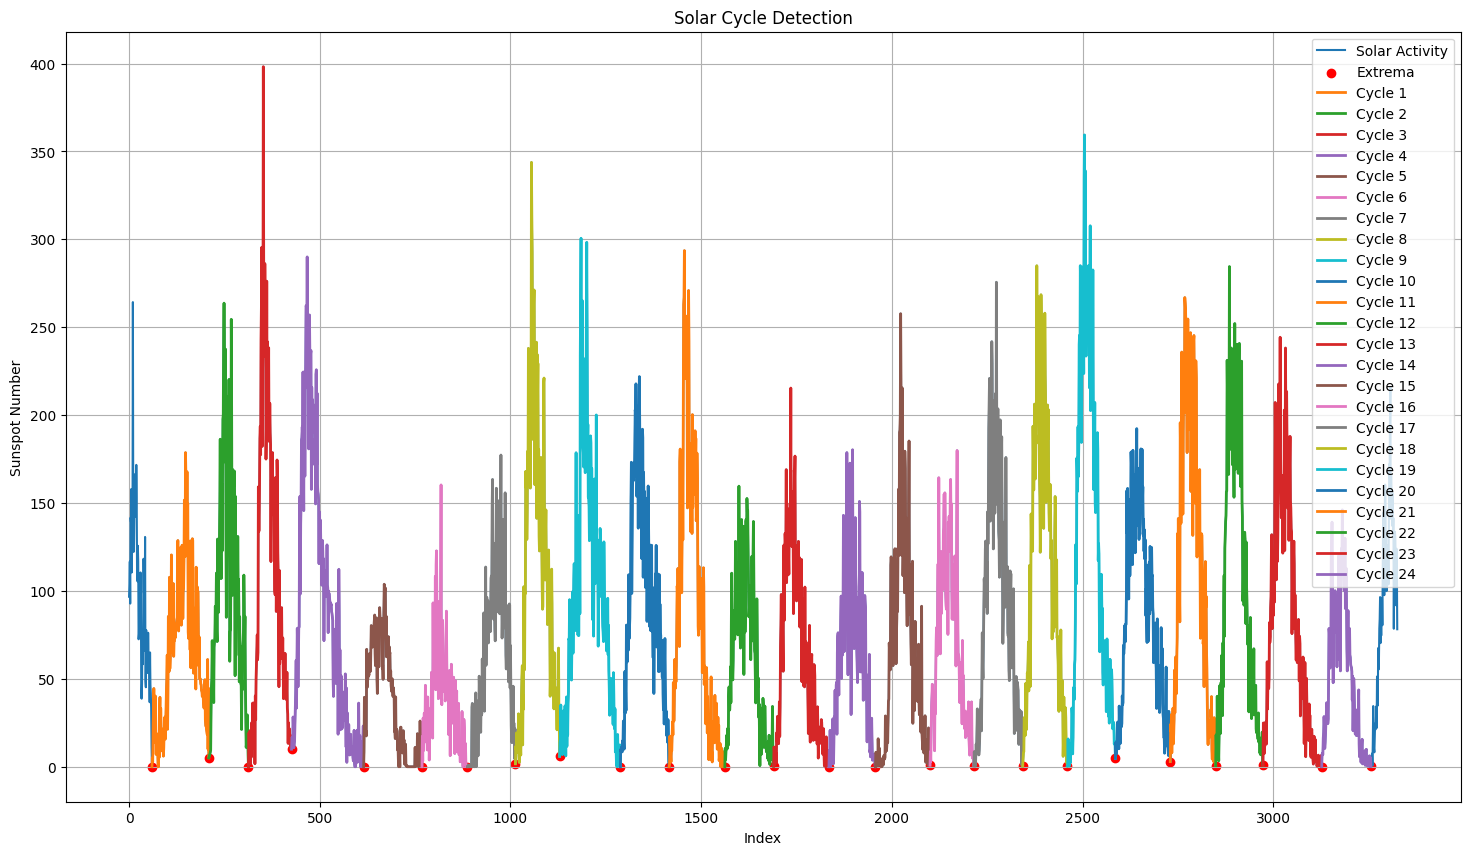

In [6]:
# Detect cycles by minima
min_min_cycles = detect_solar_cycles(
    sn["sn"], min_distance=100, split_type="min", plot=True
)

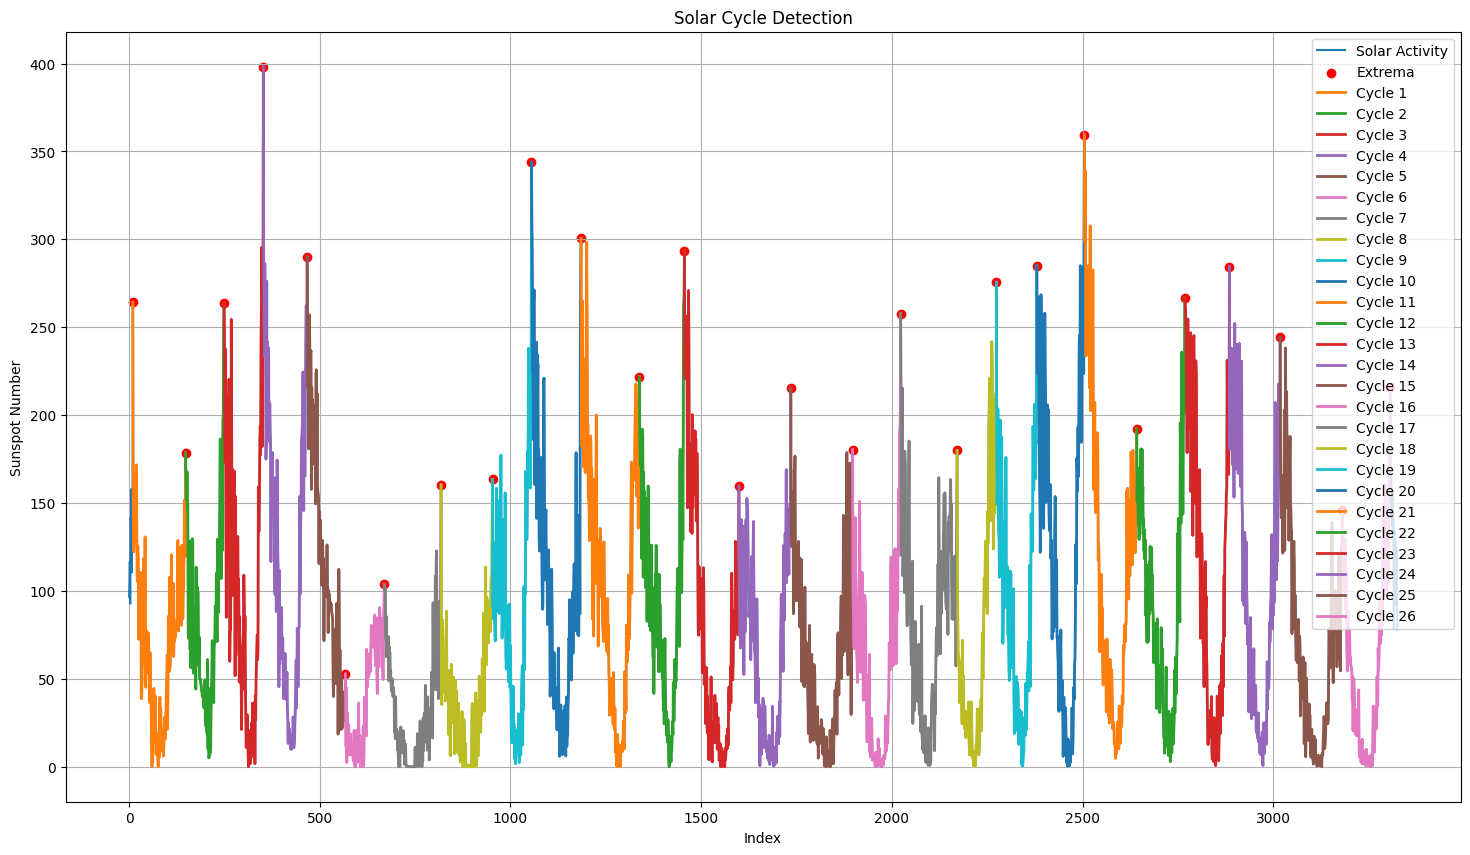

In [7]:
max_max_cycles = detect_solar_cycles(
    sn["sn"], min_distance=100, split_type="max", plot=True
)

## Plot Data

Utility function for visualizing forecasts against actual sunspot numbers.

In [8]:
def plot_forecast(x_test, forecast, timestamps, save=False, fname=""):
    """
    Plot actual vs forecasted sunspot numbers.

    Args:
        x_test: Actual sunspot values.
        forecast: FReT forecast values.
        timestamps: Corresponding datetime values.
        save: If True, save figure to file.
        fname: Filepath for saving (if save=True).
    """
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps, x_test, linewidth=3, color="black", label="SN")
    plt.plot(timestamps, forecast, "--", linewidth=3, color="red", label="FReT")
    plt.text(
        0.01,
        0.99,
        f"MAE = {np.round(mae(x_test, forecast), 2)}",
        fontsize=14,
        ha="left",
        va="top",
        transform=plt.gca().transAxes,
    )
    plt.legend(loc="upper right")
    if save:
        plt.savefig(fname)

## Predict Last N Min-Min Cycles

Train on all historical cycles and predict the last N complete cycles (defined by consecutive minima).

In [9]:
def predict_last_N_cycles(sn: np.ndarray, cycles: list[tuple(int, int)], last_N: int):
    """
    Train on historical cycles and predict the last N cycles.

    Args:
        sn: Structured array with sunspot data (contains 'sn' and 'datetime' fields).
        cycles: List of (start_idx, end_idx) tuples defining cycle boundaries.
        last_N: Number of most recent cycles to predict.

    Returns:
        List of error arrays (actual - predicted) for each predicted cycle.
    """
    errors = []  # for interval predictions in final sections

    for cycle_idx in range(-last_N, 0):
        cycle_start, cycle_stop = cycles[cycle_idx]
        x_train = sn["sn"][:cycle_start].reshape(-1, 1)
        x_test = sn["sn"][cycle_start:cycle_stop].reshape(-1, 1)

        forecast = FReT_forecast(x_train, forecast_horizon=x_test.shape[0])

        errors.append(x_test.flatten() - forecast)

        plot_forecast(
            x_test, forecast, sn["datetime"][cycle_start:cycle_stop], save=False
        )
    return errors

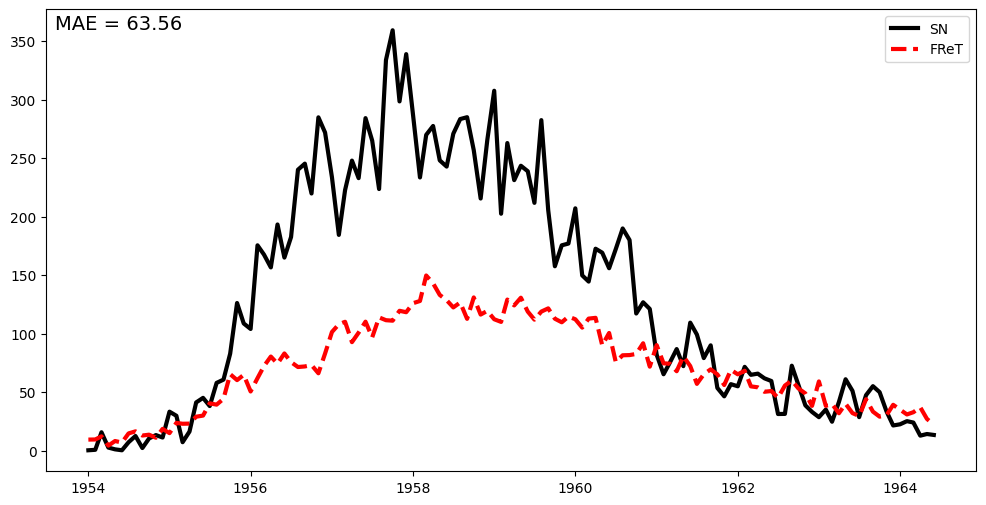

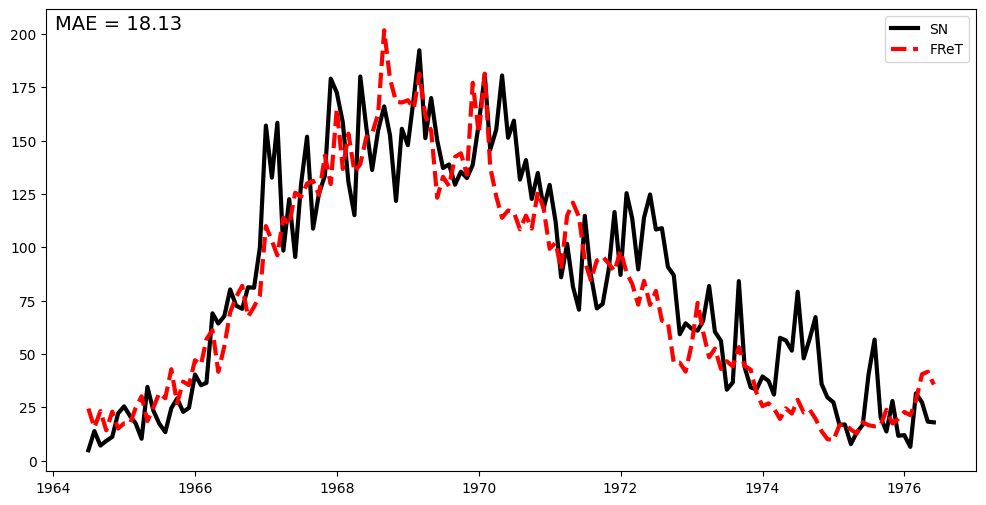

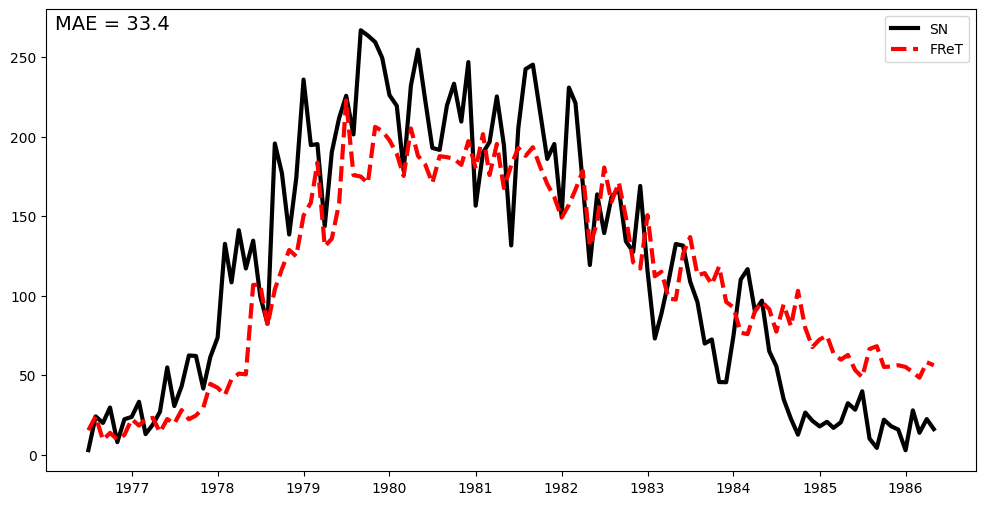

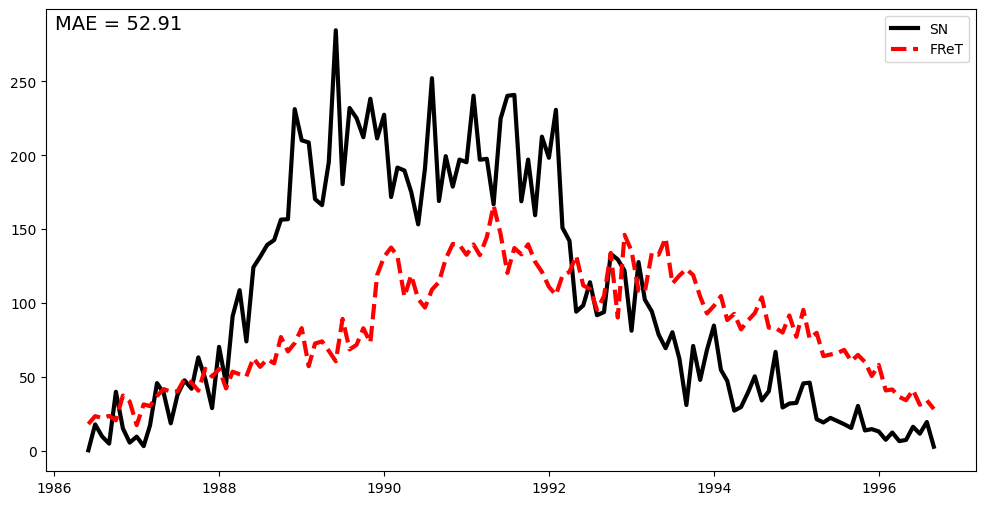

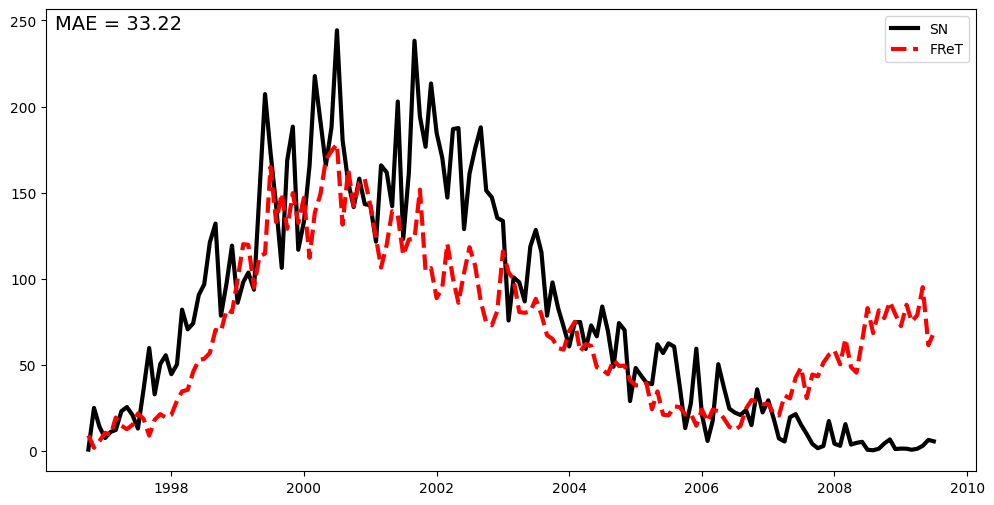

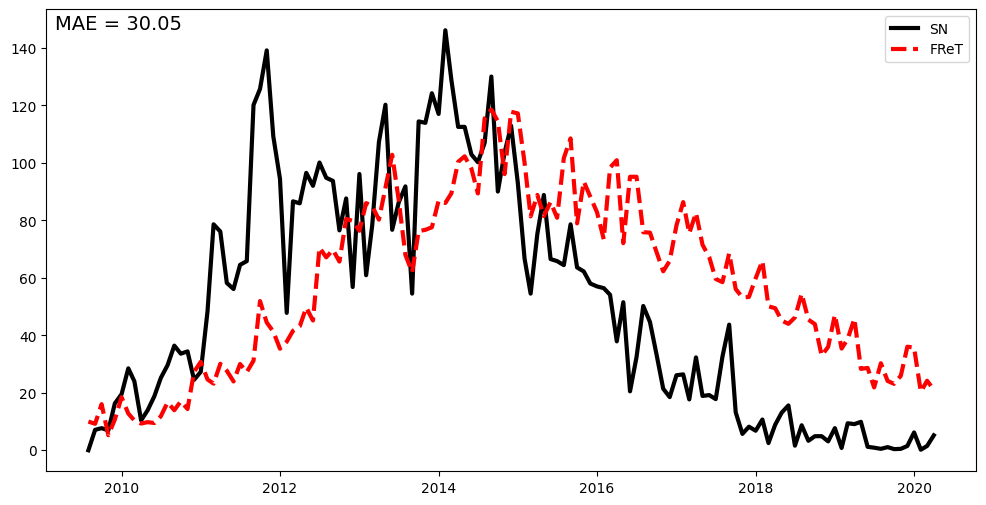

In [10]:
min_min_errors = predict_last_N_cycles(sn, cycles=min_min_cycles, last_N=6)

## Predict Last N Max-Max Cycles

Similar to min-min approach, but defining cycles by consecutive maxima. This approach captures the peak-to-peak structure of solar activity.

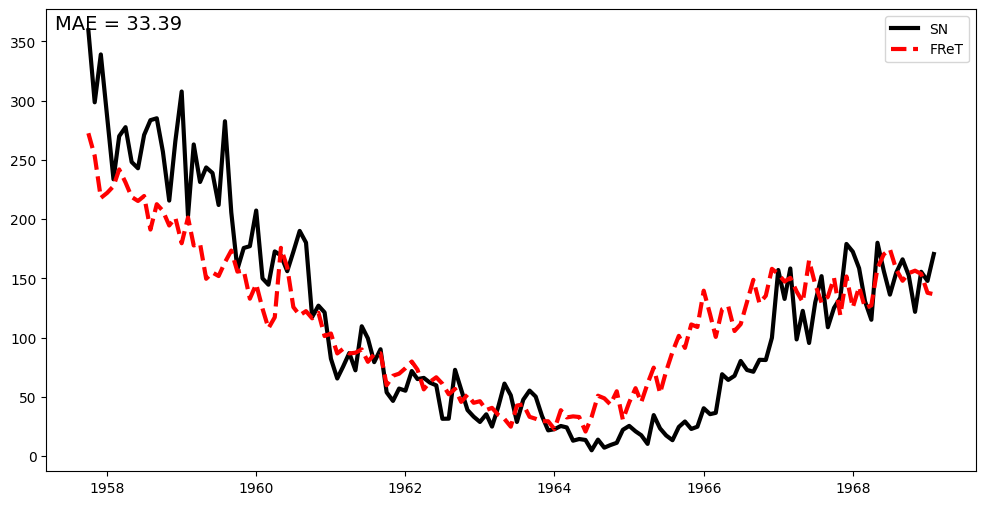

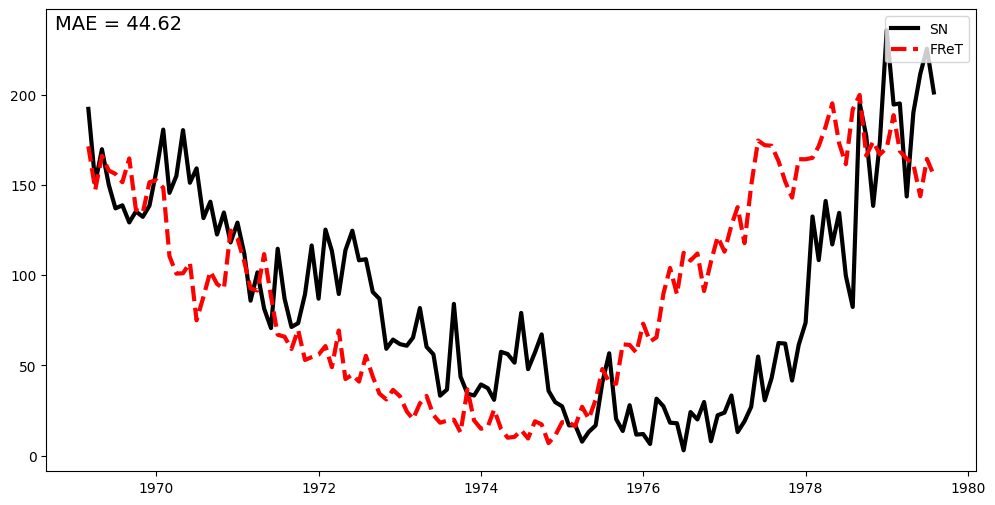

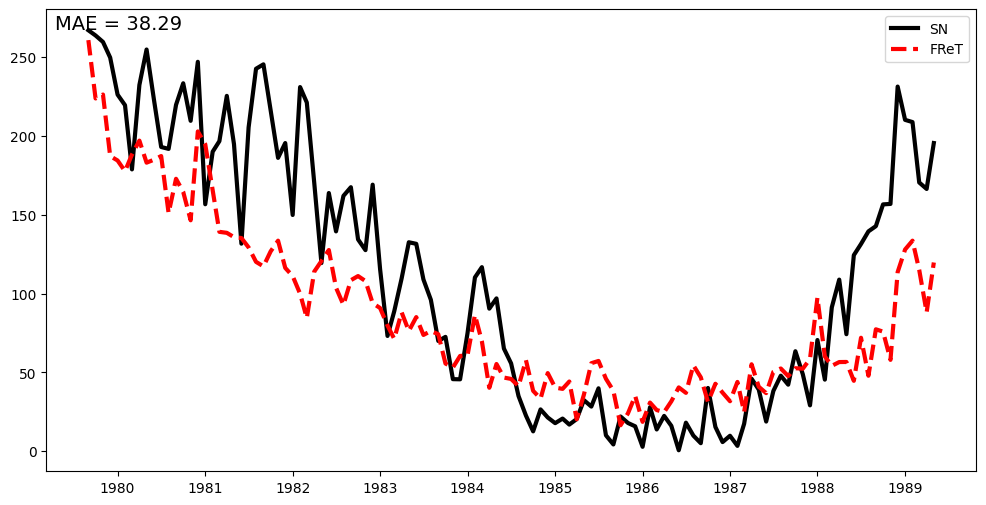

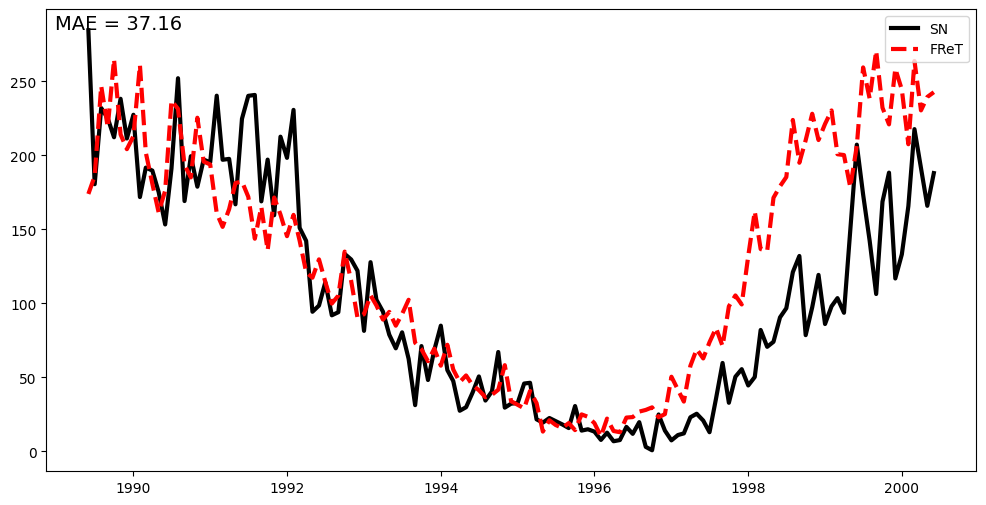

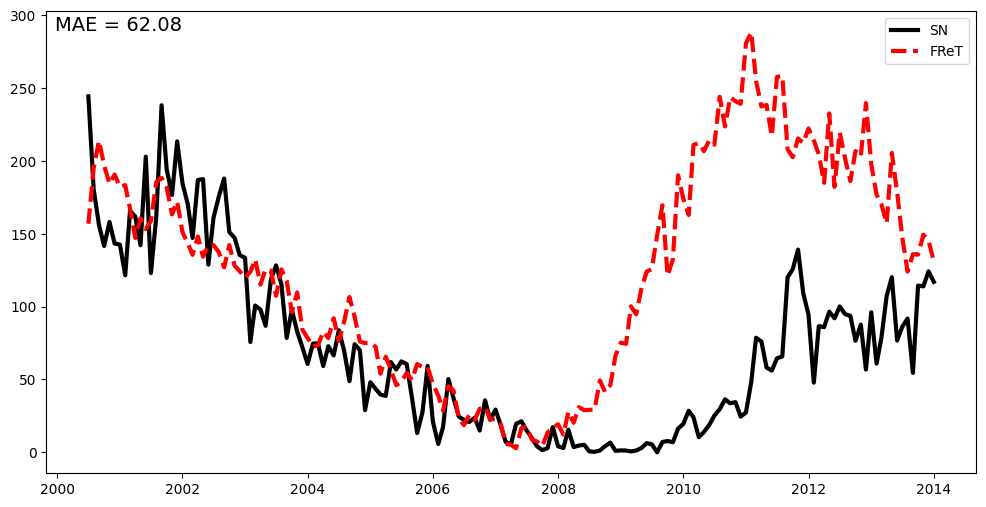

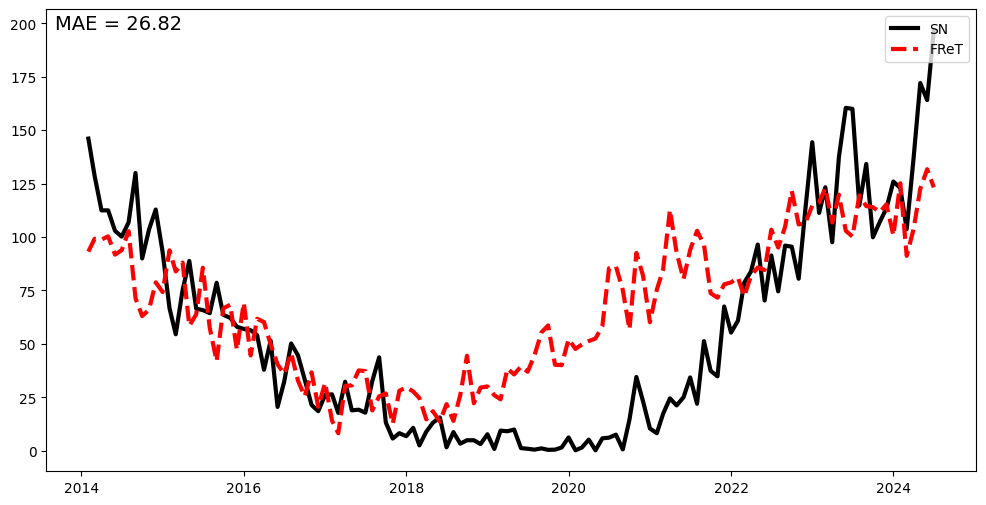

In [11]:
max_max_errors = predict_last_N_cycles(sn, cycles=max_max_cycles, last_N=6)

## Predict Current Cycle

Use all available historical data to forecast the ongoing solar cycle. We compute prediction errors from past cycles to construct confidence intervals for the forecast.

## Min-min case

### Past prediction errors

In [12]:
min_length = np.min([x.shape[0] for x in min_min_errors])
stds = np.std(np.vstack([x[:min_length] for x in min_min_errors]), axis=0)

Text(0, 0.5, 'Standard deviation')

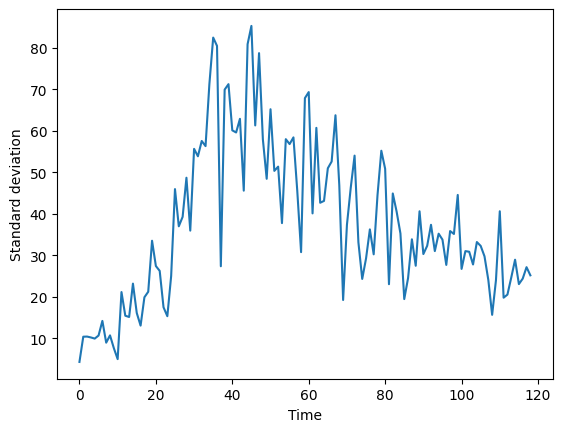

In [13]:
plt.plot(stds)
plt.xlabel("Time")
plt.ylabel("Standard deviation")

In [14]:
errors = np.hstack(min_min_errors)
q1, q2 = np.quantile(errors, q=[0.05, 0.95])

Text(0, 0.5, 'Frequency')

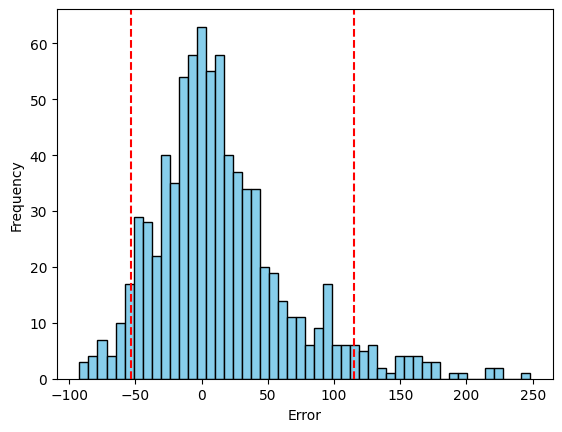

In [15]:
plt.hist(errors, bins=50, color="skyblue", edgecolor="black")
plt.axvline(x=q1, color="r", linestyle="--")
plt.axvline(x=q2, color="r", linestyle="--")

plt.xlabel("Error")
plt.ylabel("Frequency")

### Future predict

In [16]:
cycle_start = min_min_cycles[-1][1]

x_train = sn["sn"][:cycle_start].reshape(-1, 1)
x_test = sn["sn"][cycle_start:].reshape(-1, 1)

In [17]:
forecast = FReT_forecast(x_train, forecast_horizon=min_length)

Text(0.5, 1.0, '25 cycle [min-min, trained on all history]')

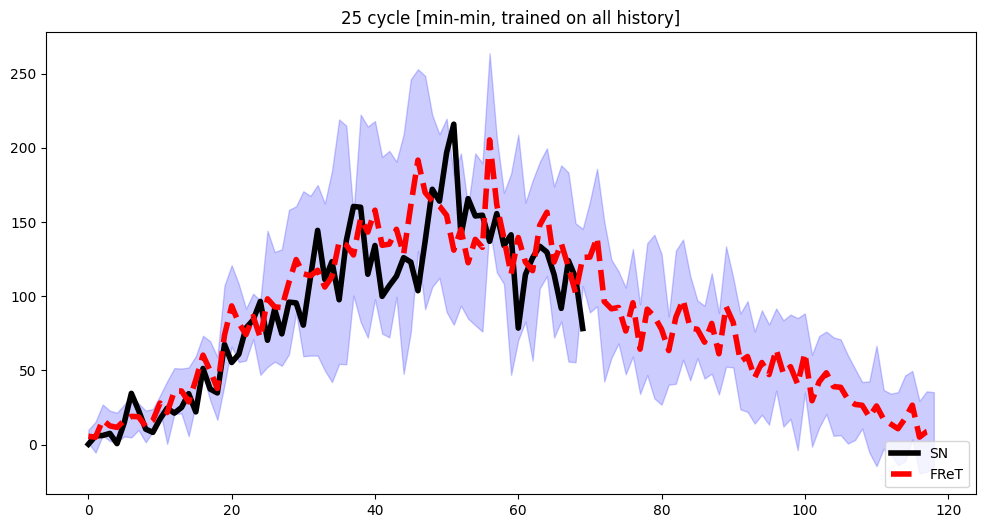

In [18]:
_x = range(len(forecast))
plt.figure(figsize=(12, 6))
plt.fill_between(_x, forecast - stds, forecast + stds, color="b", alpha=0.2)
plt.plot(x_test, linewidth=4, color="black", label="SN")
plt.plot(forecast, "--", linewidth=4, color="red", label="FReT")
plt.legend(loc="lower right")
plt.title("25 cycle [min-min, trained on all history]")

## Max-max case

### Past prediction errors

In [19]:
errors = np.hstack(max_max_errors)
q1, q2 = np.quantile(errors, q=[0.05, 0.95])

Text(0, 0.5, 'Frequency')

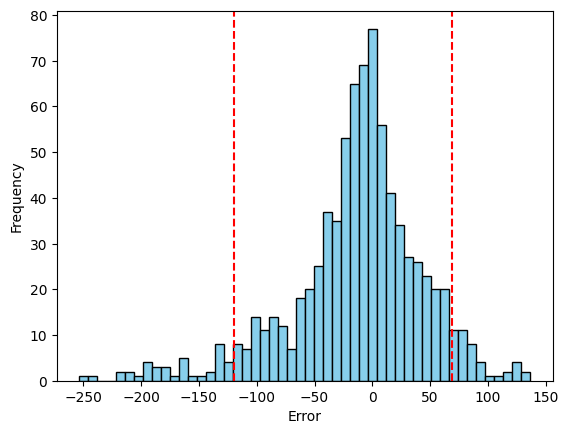

In [20]:
plt.hist(errors, bins=50, color="skyblue", edgecolor="black")
plt.axvline(x=q1, color="r", linestyle="--")
plt.axvline(x=q2, color="r", linestyle="--")

plt.xlabel("Error")
plt.ylabel("Frequency")

In [21]:
min_length = np.min([x.shape[0] for x in max_max_errors])
stds = np.std(np.vstack([x[:min_length] for x in max_max_errors]), axis=0)

Text(0, 0.5, 'Standard deviation')

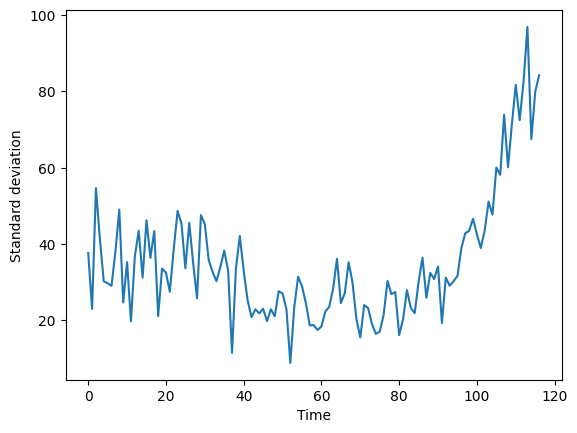

In [22]:
plt.plot(stds)
plt.xlabel("Time")
plt.ylabel("Standard deviation")

In [64]:
cycle_start = max_max_cycles[-1][1] - 10  # for max-max cycles

In [65]:
x_train = sn["sn"][:cycle_start].reshape(-1, 1)
x_test = sn["sn"][cycle_start:].reshape(-1, 1)

In [66]:
forecast = FReT_forecast(x_train, forecast_horizon=min_length)

Text(0.5, 1.0, '26 cycle [max-max, trained on all history]')

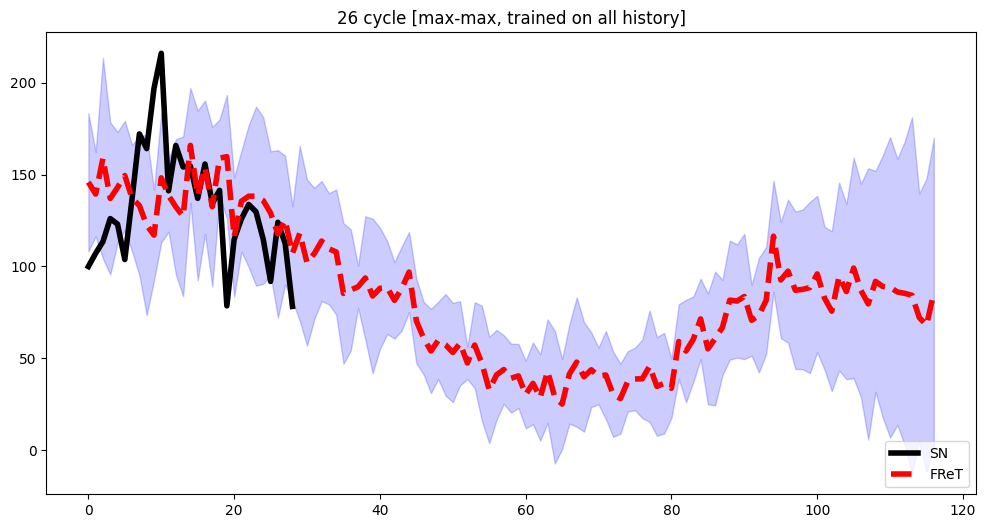

In [67]:
_x = range(len(forecast))
plt.figure(figsize=(12, 6))
plt.fill_between(_x, forecast - stds, forecast + stds, color="b", alpha=0.2)
plt.plot(x_test, linewidth=4, color="black", label="SN")
plt.plot(forecast, "--", linewidth=4, color="red", label="FReT")
plt.legend(loc="lower right")
plt.title("26 cycle [max-max, trained on all history]")